<a href="https://colab.research.google.com/github/lydiaice800408-afk/neuroscience-reaction-time-analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
data = pd.read_csv("reaction-time-data.csv")
data.head()

,cohort,subject,RT_AM,RT_PM,chronotype,caffeine,gaming
0,2018-19,1,267,271,o,c,n
1,2025-26,1,580,590,l,d,n
2,2018-19,2,403,347,o,c,n
3,2025-26,2,306,291,o,d,n
4,2018-19,3,675,317,l,c,n


In [12]:
data.shape

(142, 7)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cohort      142 non-null    object
 1   subject     142 non-null    int64 
 2   RT_AM       142 non-null    int64 
 3   RT_PM       142 non-null    int64 
 4   chronotype  142 non-null    object
 5   caffeine    142 non-null    object
 6   gaming      142 non-null    object
dtypes: int64(3), object(4)
memory usage: 7.9+ KB


In [14]:
data.groupby("cohort")[["RT_AM","RT_PM"]].mean()

,RT_AM,RT_PM
cohort,,
2018-19,301.788732,310.859155
2025-26,358.380282,343.098592


In [15]:
data["RT_change"]=data["RT_PM"]-data["RT_AM"]
data.groupby("cohort")["RT_change"].mean()

,RT_change
cohort,
2018-19,9.070423
2025-26,-15.281690


In [16]:
from scipy.stats import ttest_ind
group_2018 = data[data["cohort"] == "2018-19"]["RT_change"]
group_2025 = data[data["cohort"] == "2025-26"]["RT_change"]
result = ttest_ind(group_2018, group_2025)
print(result)

TtestResult(statistic=np.float64(1.5944837686783373), pvalue=np.float64(0.11308281460675708), df=np.float64(140.0))


In [17]:
from scipy.stats import ttest_rel
cohort_2018 = data[data["cohort"] == "2018-19"]

ttest_rel(cohort_2018["RT_AM"], cohort_2018["RT_PM"])
cohort_2025 = data[data["cohort"] == "2025-26"]

ttest_rel(cohort_2025["RT_AM"], cohort_2025["RT_PM"])

TtestResult(statistic=np.float64(1.4978058569720027), pvalue=np.float64(0.138679732026159), df=np.int64(70))

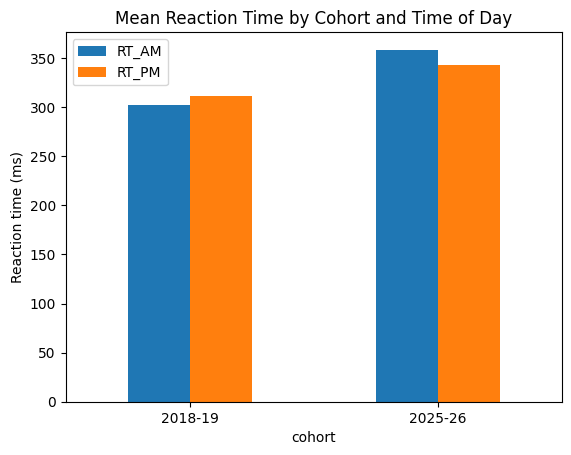

In [18]:
import matplotlib.pyplot as plt

data.groupby("cohort")[["RT_AM", "RT_PM"]].mean().plot(kind="bar")

plt.ylabel("Reaction time (ms)")
plt.title("Mean Reaction Time by Cohort and Time of Day")
plt.xticks(rotation=0)
plt.show()

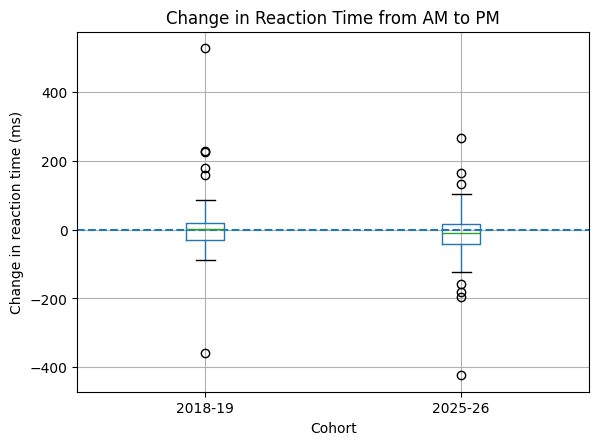

In [19]:
import matplotlib.pyplot as plt

data.boxplot(
    column="RT_change",
    by="cohort"
)

plt.ylabel("Change in reaction time (ms)")
plt.xlabel("Cohort")
plt.title("Change in Reaction Time from AM to PM")
plt.suptitle("")
plt.axhline(0, linestyle="--")

plt.show()

In [20]:
data.groupby("chronotype")["RT_change"].mean()

,RT_change
chronotype,
l,32.260870
o,-20.052083


In [21]:
data["chronotype"].value_counts()

,count
chronotype,
o,96
l,46


In [22]:
from scipy.stats import ttest_ind

lark = data[data["chronotype"] == "l"]["RT_change"]
owl = data[data["chronotype"] == "o"]["RT_change"]

result = ttest_ind(lark, owl)

print(result)

TtestResult(statistic=np.float64(3.298306609954289), pvalue=np.float64(0.0012333332093608757), df=np.float64(140.0))


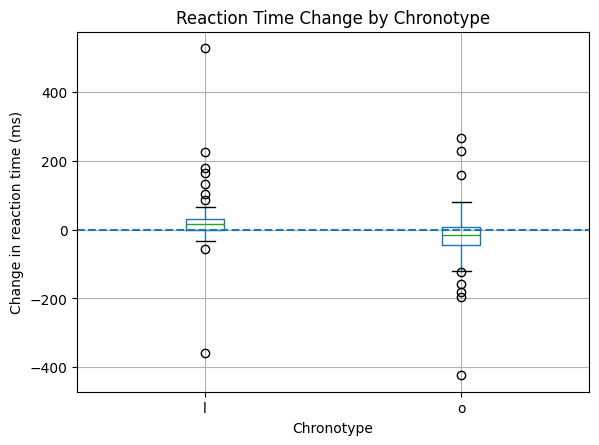

In [23]:
import matplotlib.pyplot as plt

data.boxplot(
    column="RT_change",
    by="chronotype"
)

plt.ylabel("Change in reaction time (ms)")
plt.xlabel("Chronotype")
plt.title("Reaction Time Change by Chronotype")
plt.suptitle("")
plt.axhline(0, linestyle="--")

plt.show()

In [24]:
data.groupby("caffeine")["RT_change"].mean()

,RT_change
caffeine,
c,-0.264368
d,-7.600000


In [25]:
data["caffeine"].value_counts()

,count
caffeine,
c,87
d,55


In [26]:
caffeine_c = data[data["caffeine"] == "c"]["RT_change"]
caffeine_d = data[data["caffeine"] == "d"]["RT_change"]

result = ttest_ind(caffeine_c, caffeine_d)

print(result)

TtestResult(statistic=np.float64(0.46411915712759827), pvalue=np.float64(0.643283252449917), df=np.float64(140.0))


In [27]:
data.groupby("gaming")["RT_change"].mean()

,RT_change
gaming,
n,0.053763
y,-9.102041


In [28]:
data["gaming"].value_counts()

,count
gaming,
n,93
y,49


In [29]:
gaming_n = data[data["gaming"] == "n"]["RT_change"]
gaming_y = data[data["gaming"] == "y"]["RT_change"]

result = ttest_ind(gaming_n, gaming_y)

print(result)

TtestResult(statistic=np.float64(0.5655208510435301), pvalue=np.float64(0.5726247632217651), df=np.float64(140.0))
